In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import load_data

sns.set_style("whitegrid")

In [2]:
df = load_data()

df.head()

,Age,Income,LoanAmount,CreditScore,YearsExperience,Gender,Education,City,EmploymentType,LoanApproved
0,56,48353.0,31258.0,675.0,20,Female,High School,Houston,Unemployed,0
1,69,57462.0,23262.0,586.0,6,Male,High School,San Francisco,Self-Employed,0
2,46,44219.0,26530.0,781.0,26,Male,PhD,Houston,Self-Employed,1
3,32,56307.0,11531.0,549.0,11,Male,NaN,New York,Unemployed,0
4,60,37034.0,27871.0,500.0,19,Female,High School,Chicago,Unemployed,0


In [3]:
df.shape
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Age              5000 non-null   int64  
 1   Income           4804 non-null   float64
 2   LoanAmount       5000 non-null   float64
 3   CreditScore      4806 non-null   float64
 4   YearsExperience  5000 non-null   int64  
 5   Gender           5000 non-null   str    
 6   Education        4802 non-null   str    
 7   City             5000 non-null   str    
 8   EmploymentType   5000 non-null   str    
 9   LoanApproved     5000 non-null   int64  
dtypes: float64(3), int64(3), str(4)
memory usage: 544.3 KB


,Age,Income,LoanAmount,CreditScore,YearsExperience,LoanApproved
count,5000.000000,4804.000000,5000.000000,4806.000000,5000.000000,5000.000000
mean,43.584600,49738.123022,19870.768600,575.494590,19.599000,0.230200
std,14.919094,15101.361851,8046.542413,160.550839,11.516837,0.421003
min,18.000000,-3731.000000,-10059.000000,300.000000,0.000000,0.000000
25%,31.000000,39608.500000,14455.250000,433.000000,10.000000,0.000000
50%,43.000000,49488.000000,19842.500000,579.000000,20.000000,0.000000
75%,56.000000,59917.000000,25326.750000,712.000000,29.000000,0.000000
max,69.000000,99146.000000,48353.000000,849.000000,39.000000,1.000000


In [4]:
df.isnull().sum()

Age                  0
Income             196
LoanAmount           0
CreditScore        194
YearsExperience      0
Gender               0
Education          198
City                 0
EmploymentType       0
LoanApproved         0
dtype: int64

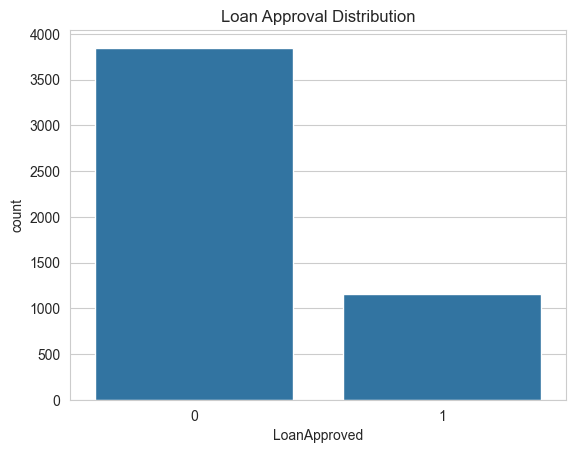

In [5]:
df["LoanApproved"].value_counts()

sns.countplot(x="LoanApproved", data=df)
plt.title("Loan Approval Distribution")
plt.show()

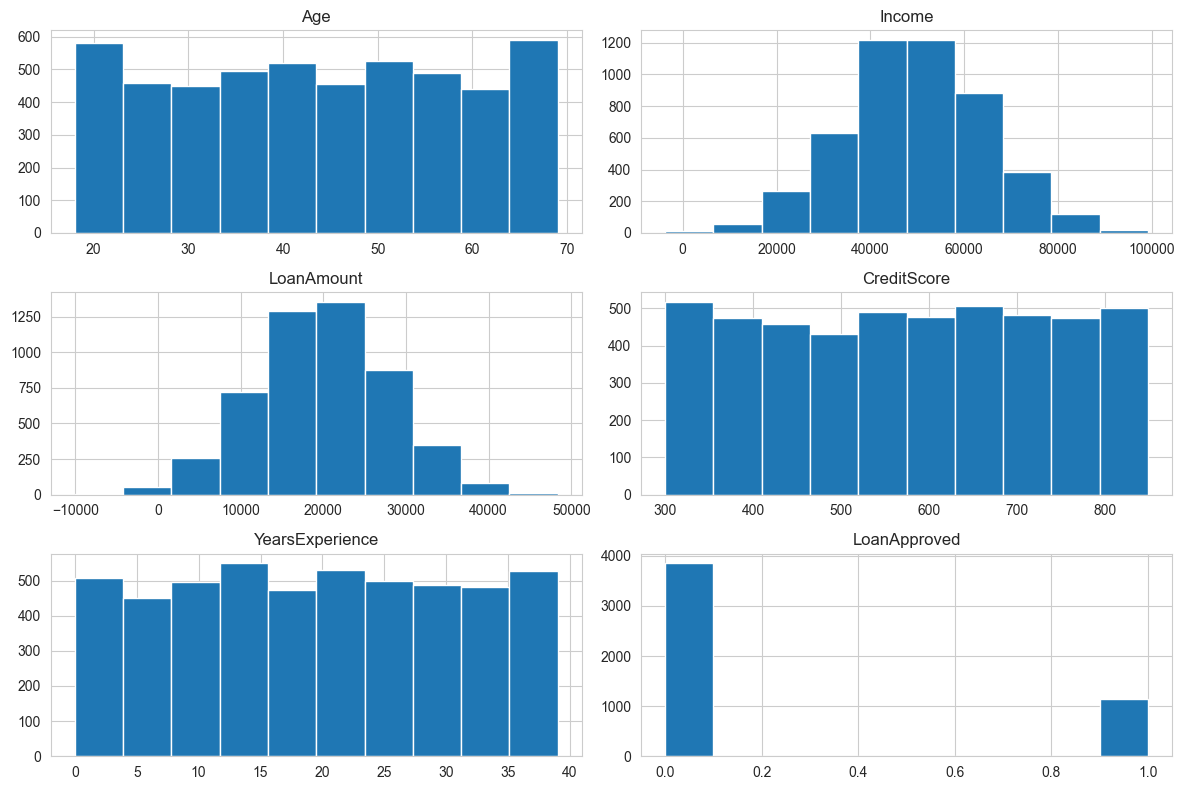

In [6]:
df.hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

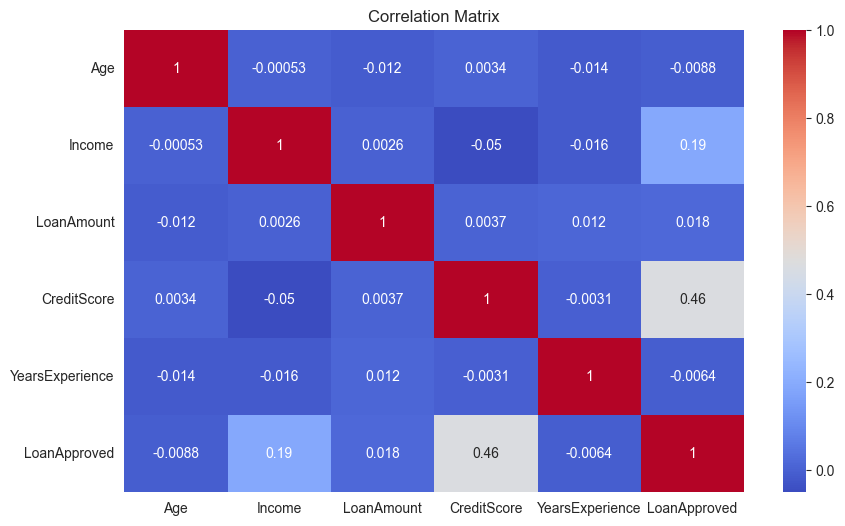

In [7]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

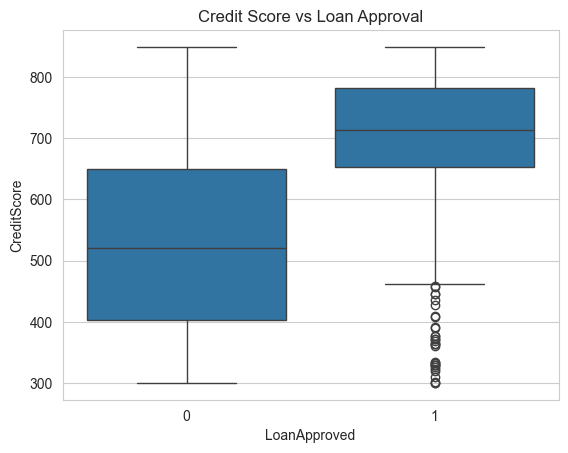

In [8]:
sns.boxplot(x="LoanApproved", y="CreditScore", data=df)
plt.title("Credit Score vs Loan Approval")
plt.show()

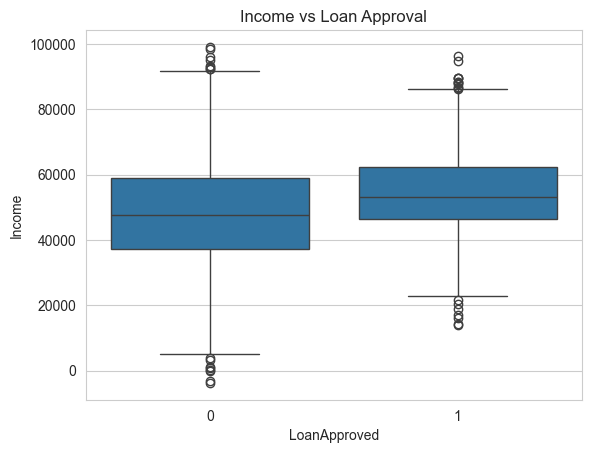

In [9]:
sns.boxplot(x="LoanApproved", y="Income", data=df)
plt.title("Income vs Loan Approval")
plt.show()

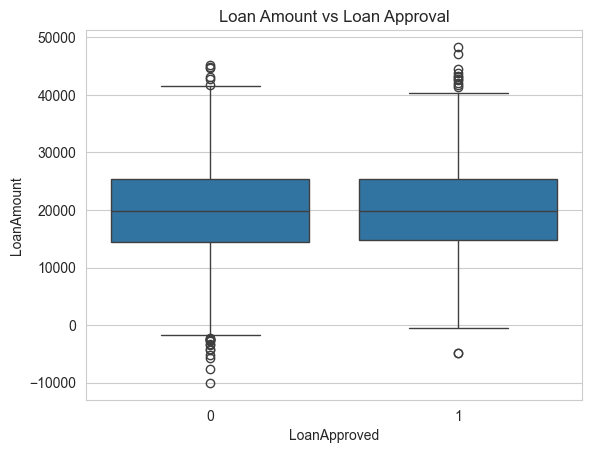

In [10]:
sns.boxplot(x="LoanApproved", y="LoanAmount", data=df)
plt.title("Loan Amount vs Loan Approval")
plt.show()

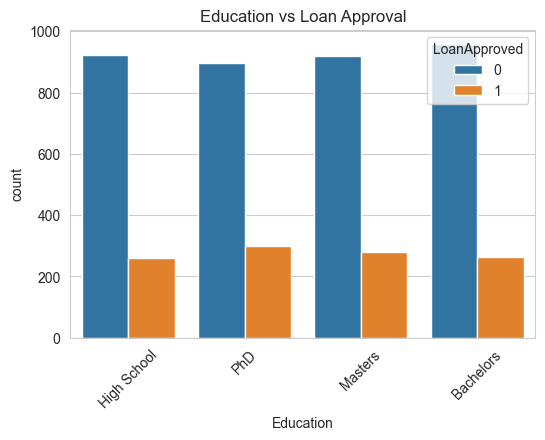

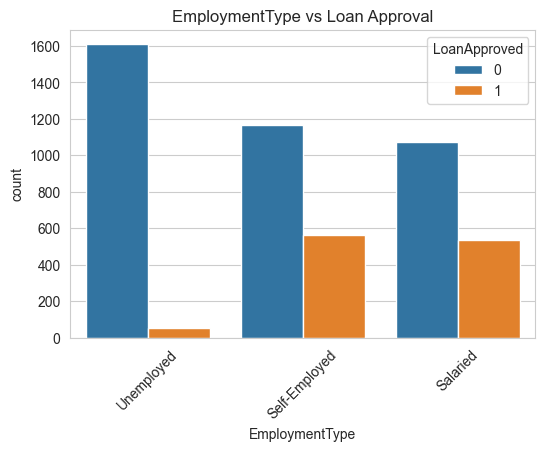

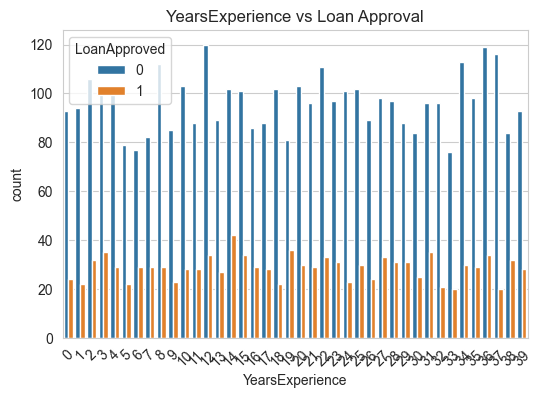

In [13]:
categorical_cols = ["Education", "EmploymentType", "YearsExperience"]

for col in categorical_cols:
    plt.figure(figsize=(6, 4))
    sns.countplot(x=col, hue="LoanApproved", data=df)
    plt.title(f"{col} vs Loan Approval")
    plt.xticks(rotation=45)
    plt.show()